<h1>Heart Disease Dataset Analysis</h1>

Heart Disease Dataset obtained from Kaggle. Dataset contains 13 features and 1 target. This dataset contains medical and behavioral information used to predict the risk of heart disease.



1.   rest_bp: Resting blood pressure (mm Hg)
2.   chest_pain: Chest pain type<br/>
     &nbsp;&nbsp;&nbsp;0: Typical angina<br/>
     &nbsp;&nbsp;&nbsp;1: Atypical angina<br/>
     &nbsp;&nbsp;&nbsp;2: Non-anginal pain<br/>
     &nbsp;&nbsp;&nbsp;3: Asymptomatic <br/>
3.   Thallium Stress Test Result<br/>
     &nbsp;&nbsp;&nbsp;0: Normal<br/>
     &nbsp;&nbsp;&nbsp;1: Fixed defect<br/>
     &nbsp;&nbsp;&nbsp;2: Reversible defect<br/>
4.   age: Age of the patient (years)
5.   fasting_bs: Fasting blood sugar > 120 mg/dl<br/>
     &nbsp;&nbsp;&nbsp;0: Fasting blood sugar <= 120 mg/dl<br/>
     &nbsp;&nbsp;&nbsp;1: Fasting blood sugar > 120 mg/dl<br/>
6.   max_hr: Maximum heart rate achieved (beats per minute)
7.   exercise_angina: Exercise-induced angina<br/>
     &nbsp;&nbsp;&nbsp;0: No exercise-induced angina<br/>
     &nbsp;&nbsp;&nbsp;1: Exercise-induced angina<br/>
8.   gender: Gender of the patient<br/>
     &nbsp;&nbsp;&nbsp;0: Female<br/>
     &nbsp;&nbsp;&nbsp;1: Male<br/>
9.   st_slope: ST segment slope<br/>
     &nbsp;&nbsp;&nbsp;0: Upsloping<br/>
     &nbsp;&nbsp;&nbsp;1: Flat<br/>
     &nbsp;&nbsp;&nbsp;2: Downsloping<br/>
10.   cholesterol: Serum cholesterol level (mg/dl)
11.   st_depression: ST depression induced by exercise relative to rest
12.   rest_ecg: Resting electrocardiographic results<br/>
      &nbsp;&nbsp;&nbsp;0: Normal<br/>
      &nbsp;&nbsp;&nbsp;1: Abnormality in ST-T wave<br/>
      &nbsp;&nbsp;&nbsp;2: Probable or definite left ventricular hypertrophy<br/>
13.   num_vessels: Number of major vessels colored by fluoroscopy<br/>
      &nbsp;&nbsp;&nbsp;0: None<br/>
      &nbsp;&nbsp;&nbsp;1: One<br/>
      &nbsp;&nbsp;&nbsp;2: Two<br/>
      &nbsp;&nbsp;&nbsp;3: Three<br/>
14.   diagnosis: Diagnosis of heart disease<br/>
      &nbsp;&nbsp;&nbsp;0: No heart disease (negative diagnosis)<br/>
      &nbsp;&nbsp;&nbsp;1: Presence of heart disease (positive diagnosis)<br/>









In [110]:
import pandas as pd
import numpy as np

import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

# Notebook Presentation

In [106]:
pd.options.display.float_format = '{:,.2f}'.format

# Load Data

In [88]:
df = pd.read_csv('heart_data.csv')

# Preliminary Data Exploration
This section explores the structure, completeness, and general characteristics of the dataset before cleaning and analysis.

In [89]:
print(f'Shape: {df.shape}')
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')
print(f'Column names: {df.columns.to_list()}')
df.head()

Shape: (297, 14)
Number of rows: 297
Number of columns: 14
Column names: ['rest_bp', 'chest_pain', 'thalassemia', 'age', 'fasting_bs', 'max_hr', 'exercise_angina', 'gender', 'st_slope', 'cholesterol', 'st_depression', 'rest_ecg', 'num_vessels', 'diagnosis']


,rest_bp,chest_pain,thalassemia,age,fasting_bs,max_hr,exercise_angina,gender,st_slope,cholesterol,st_depression,rest_ecg,num_vessels,diagnosis
0,106,3,0,67,0,142,0,0,0,223,0.30,0,2,0
1,120,2,0,50,0,158,0,0,1,219,1.60,0,0,0
2,126,3,2,35,0,156,1,1,0,282,0.00,2,0,1
3,150,3,2,63,0,154,0,0,1,407,4.00,2,3,1
4,140,3,2,46,0,120,1,1,1,311,1.80,0,2,1


In [90]:
diagnosis_map = {0: 'Negative Diagnosis', 1: 'Positive Diagnosis'}
gender_map = {0: 'Female', 1: 'Male'}
exercise_angina_map = {0: 'No Angina', 1: 'Exercise-Induced Angina'}

df.replace({'diagnosis': diagnosis_map,
            'gender': gender_map,
            'exercise_angina': exercise_angina_map}, inplace=True)

df.head()

,rest_bp,chest_pain,thalassemia,age,fasting_bs,max_hr,exercise_angina,gender,st_slope,cholesterol,st_depression,rest_ecg,num_vessels,diagnosis
0,106,3,0,67,0,142,No Angina,Female,0,223,0.30,0,2,Negative Diagnosis
1,120,2,0,50,0,158,No Angina,Female,1,219,1.60,0,0,Negative Diagnosis
2,126,3,2,35,0,156,Exercise-Induced Angina,Male,0,282,0.00,2,0,Positive Diagnosis
3,150,3,2,63,0,154,No Angina,Female,1,407,4.00,2,3,Positive Diagnosis
4,140,3,2,46,0,120,Exercise-Induced Angina,Male,1,311,1.80,0,2,Positive Diagnosis


# Data Cleaning - Check for Missing Values and Duplicates

In [91]:
print(f'NaN Values: {df.isna().sum().sum()}')
print(f'Duplicate Rows: {df.duplicated().sum()}')

NaN Values: 0
Duplicate Rows: 0


The dataframe has 297 rows and 14 columns.  

There are no NaN values or duplicate rows therefore the dataframe is already clean.

# Descriptive Statistics

In [92]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rest_bp          297 non-null    int64  
 1   chest_pain       297 non-null    int64  
 2   thalassemia      297 non-null    int64  
 3   age              297 non-null    int64  
 4   fasting_bs       297 non-null    int64  
 5   max_hr           297 non-null    int64  
 6   exercise_angina  297 non-null    object 
 7   gender           297 non-null    object 
 8   st_slope         297 non-null    int64  
 9   cholesterol      297 non-null    int64  
 10  st_depression    297 non-null    float64
 11  rest_ecg         297 non-null    int64  
 12  num_vessels      297 non-null    int64  
 13  diagnosis        297 non-null    object 
dtypes: float64(1), int64(10), object(3)
memory usage: 32.6+ KB


,rest_bp,chest_pain,thalassemia,age,fasting_bs,max_hr,st_slope,cholesterol,st_depression,rest_ecg,num_vessels
count,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00
mean,131.69,2.16,0.84,54.54,0.14,149.60,0.60,247.35,1.06,1.00,0.68
std,17.76,0.96,0.96,9.05,0.35,22.94,0.62,52.00,1.17,0.99,0.94
min,94.00,0.00,0.00,29.00,0.00,71.00,0.00,126.00,0.00,0.00,0.00
25%,120.00,2.00,0.00,48.00,0.00,133.00,0.00,211.00,0.00,0.00,0.00
50%,130.00,2.00,0.00,56.00,0.00,153.00,1.00,243.00,0.80,1.00,0.00
75%,140.00,3.00,2.00,61.00,0.00,166.00,1.00,276.00,1.60,2.00,1.00
max,200.00,3.00,2.00,77.00,1.00,202.00,2.00,564.00,6.20,2.00,3.00


In [93]:
print(df['gender'].value_counts())
print(df['gender'].value_counts(normalize=True) * 100)
print('\n')
print(df['diagnosis'].value_counts())
print(df['diagnosis'].value_counts(normalize=True) * 100)
print('\n')
print(df['exercise_angina'].value_counts())
print(df['exercise_angina'].value_counts(normalize=True) * 100)

gender
Male      201
Female     96
Name: count, dtype: int64
gender
Male     67.68
Female   32.32
Name: proportion, dtype: float64


diagnosis
Negative Diagnosis    160
Positive Diagnosis    137
Name: count, dtype: int64
diagnosis
Negative Diagnosis   53.87
Positive Diagnosis   46.13
Name: proportion, dtype: float64


exercise_angina
No Angina                  200
Exercise-Induced Angina     97
Name: count, dtype: int64
exercise_angina
No Angina                 67.34
Exercise-Induced Angina   32.66
Name: proportion, dtype: float64


The average age of the patients was 55 years old.<br/>
The highest maximum heart rate recorded was 202 bpm.<br/>
The lowest maximum heart rate recorded was 71 bpm.<br/>
The average resting blood pressure was 132 mm Hg.<br/>
The highest resting blood pressure was 200 mm Hg.<br/>
Males are the predominant gender being 67.68% of all patients.<br/>
Slightly more than half of the patients (53.87%) don't have heart disease.<br/>
The majority of the patients (67.34%) have not experienced exercise-induced angina.

# Visualising The Features

#### Resting Blood Pressure (mm Hg)

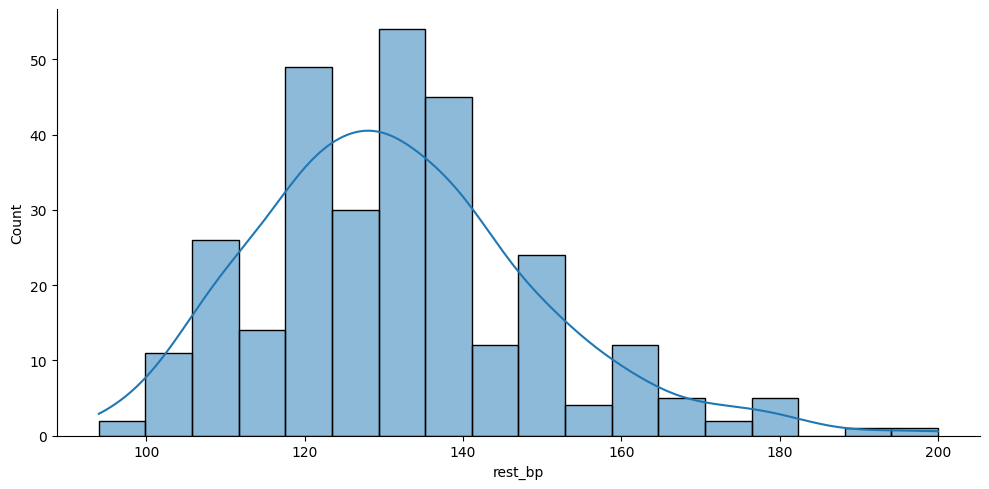

In [94]:
sns.displot(data=df, x="rest_bp", kde=True, aspect=2)
plt.show()

#### Cholesterol (mg/dl)

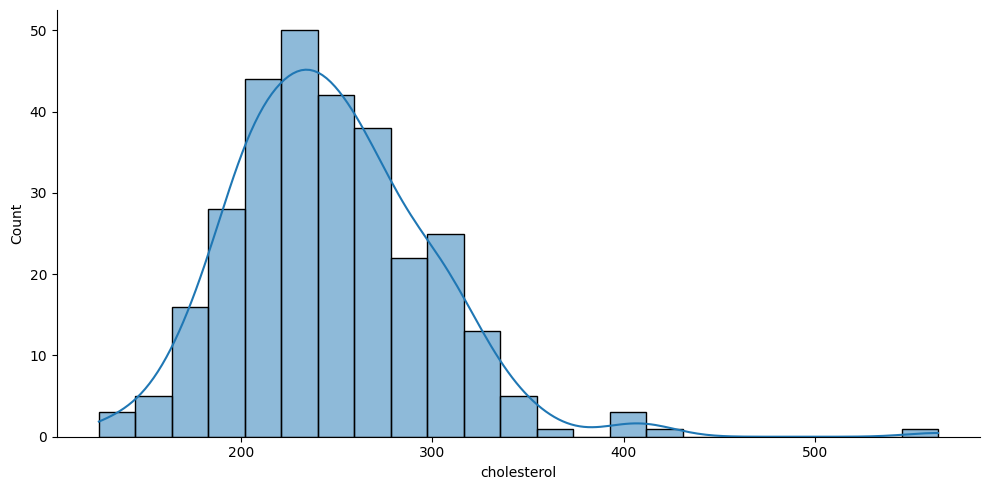

In [95]:
sns.displot(data=df, x="cholesterol", kde=True, aspect=2)
plt.show()

#### Age

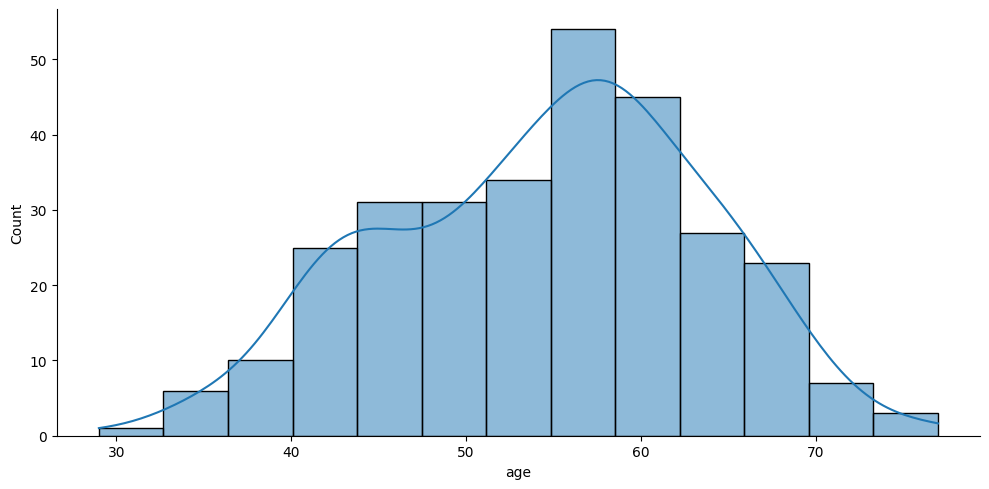

In [96]:
sns.displot(data=df, x="age", kde=True, aspect=2)
plt.show()

#### Gender

In [97]:
counts = df['gender'].value_counts().reset_index()
counts.columns = ['Gender', 'Count']

fig = px.bar(
    counts,
    x='Gender',
    y='Count',
    color='Gender',
    color_discrete_map={
        "Female": "blue",
        "Male": "orange"
    },
    labels={'Gender': 'Gender', 'Count': 'Number of Patients'},
    title='Gender Distribution'
)

fig.show()

#### Diagnosis

In [98]:
counts = df['diagnosis'].value_counts().reset_index()
counts.columns = ['Diagnosis', 'Count']

fig = px.bar(
    counts,
    x='Diagnosis',
    y='Count',
    color='Diagnosis',
    color_discrete_map={
        "Negative Diagnosis": "blue",
        "Positive Diagnosis": "orange"
    },
    labels={'Diagnosis': 'Diagnosis', 'Count': 'Number of Patients'},
    title='Diagnosis Distribution'
)

fig.show()

#### ST Depression induced by exercise relative to rest

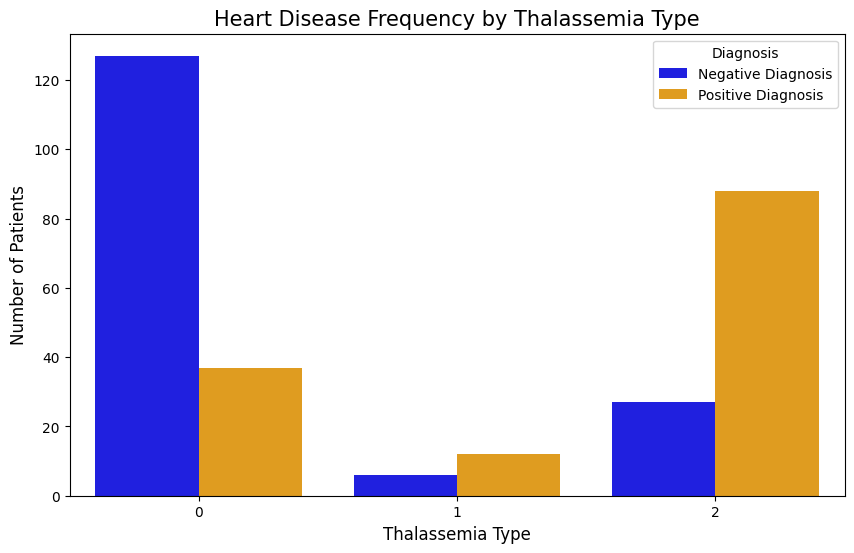

In [99]:
plt.figure(figsize=(10, 6))
custom_colors = {'Negative Diagnosis': 'blue', 'Positive Diagnosis': 'orange'}
sns.countplot(data=df, x='thalassemia', hue='diagnosis', palette=custom_colors)
plt.title('Heart Disease Frequency by Thalassemia Type', fontsize=15)
plt.xlabel('Thalassemia Type', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend(title='Diagnosis')
plt.show()

Patients with a negative diagnosis primarily fell in the 1st category of thalassemia. Patients with a positive diagnosis primmarily fell in the 3rd category for thallium stress test.  

#### Age vs. ST Depression by Heart Disease Diagnosis

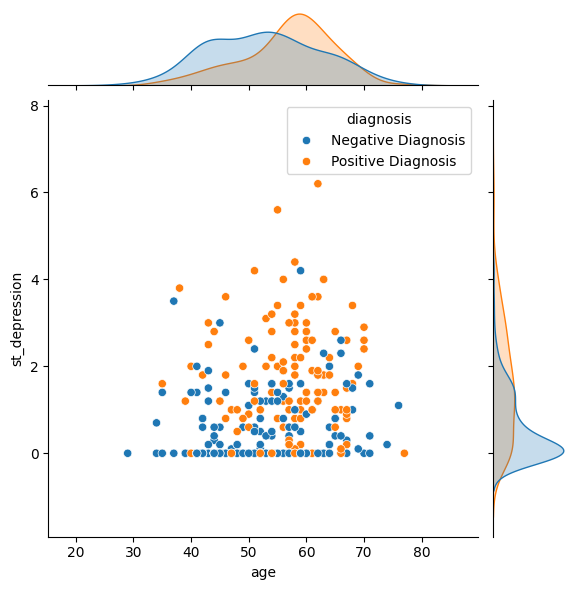

In [100]:
sns.jointplot(data=df, x='age', y='st_depression', hue='diagnosis')

plt.show()

The marginal plot for st_depression shows a clear separation between groups: the Negative group is heavily right-skewed and concentrated at 0.0, while the Positive group exhibits a significantly wider range, extending up to 4.0. This suggests st_depression is a strong indicator of heart disease. In contrast, the age distributions overlap considerably, though the Positive group peaks at a slightly higher age, indicating a weaker association. The lack of a clear linear pattern in the central scatter plot suggests that age and st_depression are relatively independent predictors.

#### Chest pain vs Number of Vessels by Heart Disease Diagnosis

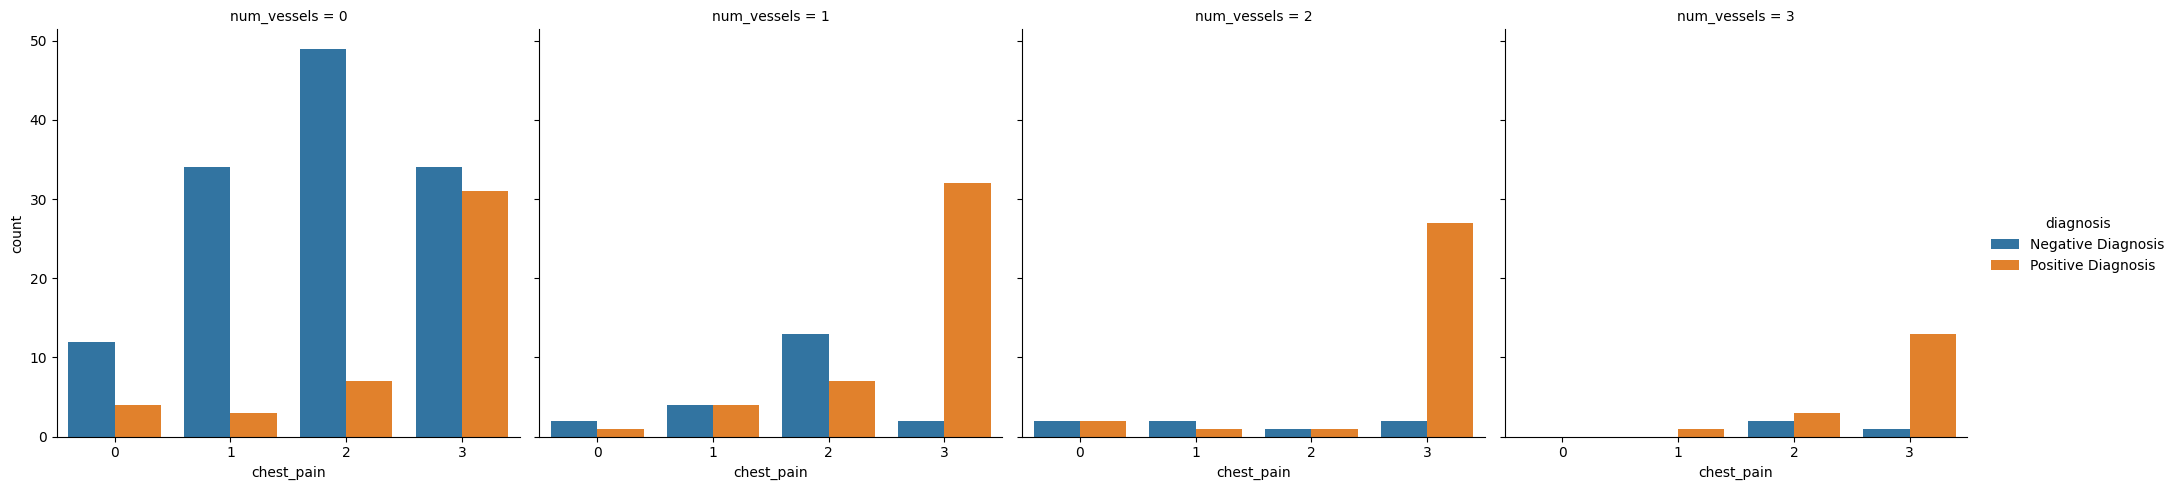

In [101]:
sns.catplot(data=df, x='chest_pain', hue='diagnosis', col='num_vessels', kind='count')
plt.show()

The majority of negative diagnostic patients' major vessels were not colored by fluoroscopy. The majority of these patients' chest pain also fell into category 2: Non-anginal pain.

Patients with a positive diagnosis had a more even spread across the number of vessels colored by fluoroscopy, however, for chest pain the highest number of patient were always found in category 3: Asymptomatic

Therefore, a patient having no blood vessels colored by fluoroscopy is a strong predictor for a negative diagnosis. Chest pain may not be present when a patient tests positive for heart disease.  

#### Maximum Heart Rate by Heart Disease Diagnosis

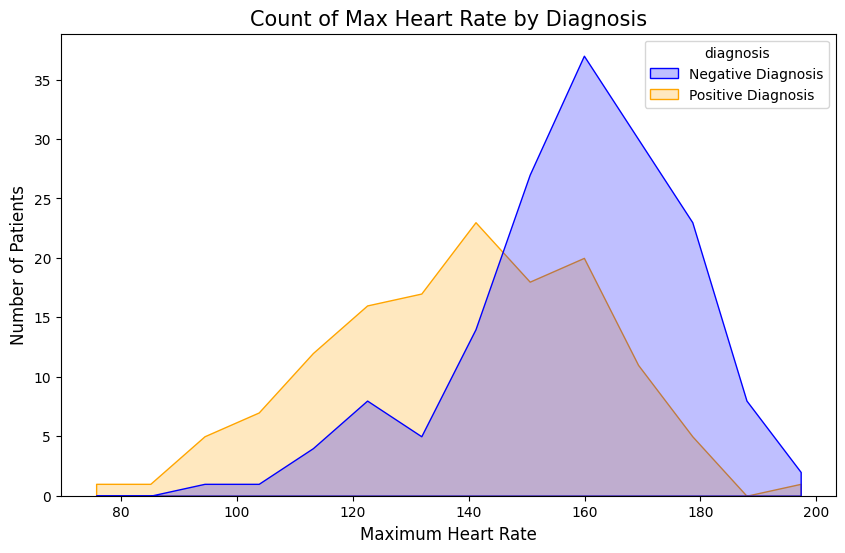

In [102]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='max_hr', hue='diagnosis',
             kde=False, element="poly", stat="count", palette=['blue', 'orange'])
plt.title('Count of Max Heart Rate by Diagnosis', fontsize=15)
plt.xlabel('Maximum Heart Rate', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.show()

Patients with a negative diagnosis have a higher maximum heart rate than patients with a positive diagnosis.

#### Correlation Matrix Heatmap for Heart Disease Diagnosis

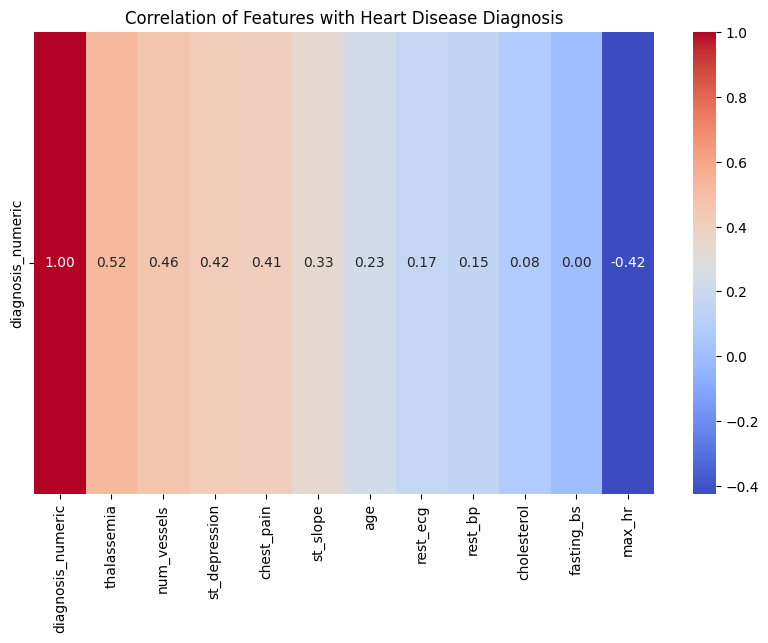

In [103]:
temp_df = df.copy()
temp_df['diagnosis_numeric'] = temp_df['diagnosis'].map({'Negative Diagnosis': 0, 'Positive Diagnosis': 1})

numeric_df = temp_df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix.sort_values(by='diagnosis_numeric', ascending=False)[['diagnosis_numeric']].T,
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation of Features with Heart Disease Diagnosis')
plt.show()

Thalassemia (0.52), number of vessels (0.46), st depression (0,42) and chest pains (0.41) are strong positive predictors for a positive diagnosis.

Thalassemia type and the number of major vessels visible on fluoroscopy are the most significant positive indicators of heart disease in this dataset.

Maximum heart rate is the strongest negative predictor (-0.42) for a positive diagnosis. A patient with a high maximum heart rate is more likely to have a negative diagnosis for heart disease.

# Inferential Statistical Analysis

### Independent Samples T-Tests

Do patients with heart disease differ significantly in age from those without heart disease?

In [107]:
positive = df[df['diagnosis'] == 'Positive Diagnosis']['age']
negative = df[df['diagnosis'] == 'Negative Diagnosis']['age']

t_stat, p_value = ttest_ind(positive, negative)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 4.004759233496147
P-value: 7.86286794560802e-05


There is a statistically significant difference between patients with heart disease and patients without heart disease.

Is there a statistically significant difference in the mean ST depression levels between patients diagnosed with heart disease and those without?

In [109]:
positive = df[df['diagnosis'] == 'Positive Diagnosis']['st_depression']
negative = df[df['diagnosis'] == 'Negative Diagnosis']['st_depression']

t_stat, p_value = ttest_ind(positive, negative)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 8.042214149140523
P-value: 2.1597372771142806e-14


Does the maximum heart rate achieved during stress testing differ significantly based on heart disease diagnosis?

In [108]:
positive = df[df['diagnosis'] == 'Positive Diagnosis']['max_hr']
negative = df[df['diagnosis'] == 'Negative Diagnosis']['max_hr']

t_stat, p_value = ttest_ind(positive, negative)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -8.036781366876342
P-value: 2.2397153233936717e-14


Due to the extremely low value of the p-value, it is almost certain that both st depression and maximum heart rate are reliable biological markers for heart disease in this population.

The T statistic for st depression shows that the positive diagnosis group have a significantly higher average st depression than the negative diagnosis group.

The T statistic for the maximum rate is -8.04, this indicates that the average maximum heart rate for the positive diagnosis group is significantly lower than the aveage maximum heart for the negative diagnosis group.

### Chi-Square Tests

Is there a significant association between the type of thalassemia defect and heart disease diagnosis?

In [111]:
contingency_table = pd.crosstab(df['thalassemia'], df['diagnosis'])
print("Contingency Table:")
print(contingency_table)
print("-" * 30)
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")

Contingency Table:
diagnosis    Negative Diagnosis  Positive Diagnosis
thalassemia                                        
0                           127                  37
1                             6                  12
2                            27                  88
------------------------------
Chi-Square Statistic: 82.4601
P-value: 1.2417e-18


Is the presence of exercise-induced angina significantly associated with a positive heart disease diagnosis?

In [113]:
contingency_table = pd.crosstab(df['exercise_angina'], df['diagnosis'])
print("Contingency Table:")
print(contingency_table)
print("-" * 30)
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")

Contingency Table:
diagnosis                Negative Diagnosis  Positive Diagnosis
exercise_angina                                                
Exercise-Induced Angina                  23                  74
No Angina                               137                  63
------------------------------
Chi-Square Statistic: 50.9426
P-value: 9.5109e-13


Thalassemia matches what was observed with the correlation matrix in that it is statistically the most significant predictor of heart disease with a P-value of 1.2417e-18. Exercise-induced angina is also statistically highly significant with a P-value of 9.5109e-13.

Does the prevalence of heart disease differ significantly between male and female patients in this study population?

In [114]:
contingency_table = pd.crosstab(df['gender'], df['diagnosis'])
print("Contingency Table:")
print(contingency_table)
print("-" * 30)
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")

Contingency Table:
diagnosis  Negative Diagnosis  Positive Diagnosis
gender                                           
Female                     71                  25
Male                       89                 112
------------------------------
Chi-Square Statistic: 21.8516
P-value: 2.9457e-06


There is a statistically significant association between gender and heart disease, with a P-value of 2.9457e-06. Males have a higher possibillity of developing heart disease than females.

### Interpretation of Statistical Findings

Statistical testing identified significant differences in age, ST depression, and maximum heart rate between diagnosis groups. Additionally, categorical variables such as thalassemia, exercise-induced angina, and gender demonstrated significant associations with heart disease diagnosis. These findings suggest that both physiological and demographic factors may play important roles in heart disease occurrence within this dataset.

# Key Findings

*   Thalassemia type is the strongest predictor for heart disease. It had the highest correlation efficient (0.52) and the lowest p-value (1.2417e-18). A "Reversible Defect" result is a significant indicator for heart disease, while a "Normal" result is the strongest indicator of a negative diagnosis.
*   ST Depression is also a strong predictor for heart disease. A higher "sag" in the EKG during exercise is a definitive marker for heart disease.
*   Maximum heart rate has a negative relationship with heart health. The higher the maximum heart rate is the lower the chance of heart disease.
*   Age and Gender are weaker predictors for heart disease, although still statistically significant. Patients that are male have a higher chance of developing heart disease. Patients that are older (above 50) have a higher chance of developing heart disease.
*   For this particular study population it was identified that as the number of colored vessels from fluoroscopy increased, the likelihood of a positive diagnosis dropped significantly.
*   Cholesterol and Blood sugar were shown to have almost no correlation with heart disease in this specific group of patients.







# Limitations

*   Relatively small sample size (297 patients).
*   A large gender imbalance (201 males vs. 96 females). The dataset is also skewed toward middle-aged individuals.
*   Correlations do not imply causation.
*   The dataset represents a single point in time for each patient. It doesn't account for changes as time progresses (how a patient's heart rate or ST depression changes over several years).
* Dataset may not generalize broadly.







# Conclusion

This analysis successfully identified the primary predictors of heart disease within this clinical dataset. Through rigorous exploratory data analysis and statistical testing, it was determined that clinical stress-test indicators—specifically Thalassemia type, ST Depression, and Maximum Heart Rate—are the most significant predictors of a positive diagnosis. These features demonstrated far greater predictive power (with p-values as low as 1.24e-18) compared to traditional demographic factors like Age and Gender, or standard metrics like Cholesterol.

The findings highlight a "clinical profile" for high-risk patients: those exhibiting a reversible thalassemia defect, lower maximum heart rates during exertion, and significant ST segment depression on an EKG. However, it is important to note the limitations of this study, including the relatively small sample size of 297 patients and a notable gender imbalance. While these results are statistically definitive for this specific group, the geographical and time constraints of the data mean that further research using larger, more diverse, and modern datasets is required to ensure these findings generalize to the global population.

Ultimately, this project proves that while age and gender play a role, the biological response of the heart under stress remains the most critical factor in diagnosing coronary heart disease.

# Future Improvements

*   The next logical step is to transition from statistical testing to predictive modelling. Implementing a Logistic Regression model would allow for the calculation of the specific probability of heart disease for new patients.
*   To address the current limitation of a small sample size, future work should incorporate larger, multi-centre datasets.
*   Tracking patient data over months or years would help identify early warning trends and the rate of disease progression, rather than just the current state of the heart.
*   To make these insights accessible to medical professionals, the project could be expanded into a dynamic dashboard.



